# 03 — Fleet clustering, efficiency ranking and outliers (models.md §4)

Weekly metrics per operator and per machine → within-machine-type z-scores → StandardScaler +
KMeans (k 3–5 by silhouette) → cluster names from centroids, efficiency index and rank in site,
outliers (|z| > 2.5 or DBSCAN noise) with a plain-language reason, and a PCA scatter for the
manager dashboard. Built from the full 90-day synthetic run (`data/output/`).

* **Split by time.** 2026-06-01 is a Monday, so days 1–70 are exactly weeks 1–10: every scaler,
  KMeans, PCA and DBSCAN is fitted on those weeks. Weeks 11–13 (days 71–90; week 13 has 6 days)
  are the holdout.
* **Within machine type.** Every segment (entity × week × machine type) is standardised against
  its entity_type × machine_type group. Operators drive all four types, so an operator's week is
  the productive-hours-weighted mean of their per-type z-scores.
* `anomaly_label` / `anomaly_type` are **never read**: `anomaly_count` = `machine_fault` events
  from the anomaly detector (`ml.inference.anomaly`), i.e. what becomes an `alerts` row.
  `operators.personality` is read **only** in the evaluation cells (adjusted Rand index).
* Feature and inference code lives in `ml/inference/clustering.py`, so notebook and backend
  compute the same thing.

In [1]:
import json, sys, warnings
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, silhouette_score

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import ml.inference.anomaly as A
import ml.inference.clustering as C
import ml.inference.task_time as T
from ml.inference.clustering import FEATURE_COLUMNS, Z_COLUMNS

DATA = ROOT / "data" / "output"
ART = ROOT / "ml" / "artifacts" / "clustering"
ART.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
FIT_END = date(2026, 8, 10)          # weeks starting before this = days 1-70 (fit)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

## 1 — Data

In [2]:
read = lambda name, dates=(): pd.read_csv(DATA / f"{name}.csv", parse_dates=list(dates))
tasks = read("tasks", ["scheduled_start", "actual_start", "actual_end"])
weather = read("weather", ["ts"])
operators = read("operators").drop(columns=["personality"])   # hidden, never a feature
machines = read("machines")
shifts = read("shifts", ["start_time", "end_time"])
fatigue_log = read("fatigue_log", ["ts"])
maintenance_log = read("maintenance_log", ["event_date"])
safety_events = read("safety_events", ["ts"])
telemetry = pd.read_parquet(DATA / "telemetry.parquet",
                            columns=sorted({*A.INPUT_COLUMNS, "shift_id", "fuel_rate_lph"}))
print(len(telemetry), "telemetry rows,", len(shifts), "shifts,", len(tasks), "tasks")

652228 telemetry rows, 1448 shifts, 7213 tasks


### anomaly_count: machine_fault events from the anomaly detector
The detector's batch path from `ml/01_anomaly.ipynb` (rolling features → per type × state
IsolationForest → settle / persistence gate). One event = one run of consecutive fault minutes.
Sensor glitches are the sensor, not the machine or the operator, so they don't count.

In [3]:
feats, glitch = A.build_features(telemetry[A.INPUT_COLUMNS])
art_a = A.load_artifacts()
mtype = machines.set_index("machine_id").machine_type
flagged = np.zeros(len(feats), dtype=bool)
for mt, idx in feats.groupby(feats.machine_id.map(mtype)).groups.items():
    flagged[feats.index.get_indexer(idx)] = A.score_frame(feats.loc[idx], mt, art_a)["flagged"]
kind = pd.Series(A.classify(feats, flagged, glitch))
anomaly_events = C.anomaly_event_starts(feats.ts, feats.machine_id, kind)
print(kind.value_counts().to_dict(), "->", len(anomaly_events), "machine_fault events")

{'normal': 651785, 'machine_fault': 272, 'sensor_glitch': 171} -> 127 machine_fault events


### time_ratio: actual ÷ p50 from `ml.inference.task_time`
Two p50s for every completed task:
* **planning p50** — `predict_task_time` as the app shows it (what `tasks.predicted_p50_min` holds);
* **fleet p50** — the same model with the operator's own history (`operator_avg_time_ratio`) left
  unknown (`C.fleet_p50`). Used in the tuning round below.

The task-time model was trained on days 1–70, so on the fit weeks its p50 is in-sample (closer
to the actual) and on the holdout weeks it is not.

In [4]:
done = tasks[(tasks.status == "completed") & tasks.actual_duration_min.notna()]
ft = T.build_feature_table(tasks, weather, operators, machines, shifts, fatigue_log,
                           maintenance_log, T.load_artifacts()["reference"])
ft = ft[ft.task_id.isin(done.task_id)]
plan = T.predict_task_time(ft[T.INPUT_COLUMNS], explain_factors=False)
tasks["planning_p50_min"] = tasks.task_id.map({p["task_id"]: p["p50_min"] for p in plan})
tasks["fleet_p50_min"] = tasks.task_id.map(C.fleet_p50(ft))
print(tasks[["planning_p50_min", "fleet_p50_min"]].notna().sum().to_dict())

{'planning_p50_min': 6379, 'fleet_p50_min': 6379}


## 2 — Weekly metrics (models.md §4 list)

In [5]:
tel = telemetry[["shift_id", "fuel_rate_lph", "is_idle"]]
segments = {v: C.build_weekly_segments(tel, tasks, shifts, machines, safety_events, anomaly_events,
                                       p50_column=col)
            for v, col in [("v1", "planning_p50_min"), ("v2", "fleet_p50_min")]}
for s in segments.values():
    s["fit"] = s.week_start < FIT_END
seg = segments["v2"]
print(seg.groupby(["entity_type", "fit"]).size().unstack())
seg.head()

fit          False  True 
entity_type              
machine         36    120
operator       163    527


,entity_type,entity_id,site_id,week_start,machine_type,productive_hours,fuel_per_productive_hour,idle_pct,productivity_per_hour,time_ratio,anomaly_count,safety_event_count,fit
0,machine,M01,S1,2026-06-01,excavator,55.333333,17.075548,15.392457,110.240964,0.999046,2,15,True
1,machine,M01,S1,2026-06-08,excavator,77.783333,17.207454,13.301133,87.293765,1.018760,0,24,True
2,machine,M01,S1,2026-06-15,excavator,68.3,17.822082,18.399044,104.31918,0.990100,0,30,True
3,machine,M01,S1,2026-06-22,excavator,50.4,17.705804,20.042306,95.734127,1.018726,0,23,True
4,machine,M01,S1,2026-06-29,excavator,70.433333,17.406578,19.011115,89.517274,1.032316,0,24,True


In [6]:
# Sanity: totals rebuild from the raw tables
chk = seg[seg.entity_type == "machine"]
eng_h = chk.productive_hours / (1 - chk.idle_pct / 100)
assert np.isclose(eng_h.sum(), len(telemetry) / 60)
assert np.isclose((chk.fuel_per_productive_hour * chk.productive_hours).sum(),
                  telemetry.fuel_rate_lph.sum() / 60)
assert chk.anomaly_count.sum() == len(anomaly_events)
n_safety = (~safety_events.event_type.isin(C.EXCLUDED_SAFETY_EVENTS)).sum()
print("safety events counted:", chk.safety_event_count.sum(), "of", n_safety,
      f"(excluded: {', '.join(C.EXCLUDED_SAFETY_EVENTS)})")
assert chk.safety_event_count.sum() == n_safety

safety events counted: 2837 of 2837 (excluded: fatigue_high)


In [7]:
def prepare(seg):
    scalers = C.fit_type_scalers(seg[seg.fit])
    ew = C.entity_weeks(seg, scalers)
    ew["fit"] = ew.week_start < FIT_END
    return scalers, ew

prep = {v: prepare(s) for v, s in segments.items()}
scalers, ew = prep["v2"]
ew.groupby("entity_type")[["productive_hours", "idle_pct", "fuel_per_productive_hour",
                           "time_ratio", "anomaly_count", "safety_event_count"]].describe().T.round(2)

entity_type                     machine  operator
productive_hours         count   156.00    260.00
                         mean     57.44     34.47
                         std       9.91      5.33
                         min      25.47     18.68
                         25%      50.53     30.98
                         50%      58.40     35.93
                         75%      64.42     38.87
                         max      83.18     42.75
idle_pct                 count   156.00    260.00
                         mean     17.54     17.22
                         std       3.80      8.65
                         min       9.91      7.08
                         25%      14.49     10.63
                         50%      16.81     15.38
                         75%      20.39     20.29
                         max      27.54     41.59
fuel_per_productive_hour count   156.00    260.00
                         mean     19.09     19.11
                         std       3.98      2.57
                         min      14.42     14.30
                         25%      15.79     17.18
                         50%      17.46     18.86
                         75%      22.37     20.81
                         max      28.02     27.10
time_ratio               count   156.00    260.00
                         mean      1.02      1.03
                         std       0.04      0.05
                         min       0.91      0.90
                         25%       1.00      0.99
                         50%       1.02      1.02
                         75%       1.04      1.06
                         max       1.12      1.18
anomaly_count            count   156.00    260.00
                         mean      0.81      0.49
                         std       1.43      0.81
                         min       0.00      0.00
                         25%       0.00      0.00
                         50%       0.00      0.00
                         75%       1.00      1.00
                         max       7.00      4.00
safety_event_count       count   156.00    260.00
                         mean     18.19     10.91
                         std       5.60      4.24
                         min       7.00      3.00
                         25%      15.00      8.00
                         50%      18.00     10.00
                         75%      21.00     13.00
                         max      39.00     25.00

## 3 — v1: models.md §4 as written

Planning p50 for time_ratio, all six features weighted equally after StandardScaler, KMeans k in
3..5 by silhouette (`n_init=10, random_state=42`), fitted per entity type on the fit weeks.

In [8]:
def fit_all(ew, weights=None):
    weights = weights or {}
    return {et: C.fit_entity_model(ew[(ew.entity_type == et) & ew.fit], weights.get(et))
            for et in C.ENTITY_TYPES}

def predict(ew, model):
    return model["kmeans"].predict(C.cluster_space(ew, model))

# evaluation only: the hidden personality never enters a feature
personality = pd.read_csv(DATA / "operators.csv", usecols=["operator_id", "personality"]) \
                .set_index("operator_id").personality

def evaluate(ew, model):
    op = ew[ew.entity_type == "operator"]
    fit = op[op.fit & (op.productive_hours >= C.MIN_FIT_HOURS)]
    hold = op[~op.fit]
    per_op = fit.groupby("entity_id")[Z_COLUMNS].mean().reset_index()   # operator's average week
    evaluate.last_per_op = pd.crosstab(per_op.entity_id.map(personality), predict(per_op, model))
    return {
        "ari_operator_weeks_fit": adjusted_rand_score(fit.entity_id.map(personality), predict(fit, model)),
        "ari_operator_weeks_holdout": adjusted_rand_score(hold.entity_id.map(personality), predict(hold, model)),
        "ari_operators_mean_week": adjusted_rand_score(per_op.entity_id.map(personality), predict(per_op, model)),
        "n_fit": len(fit), "n_holdout": len(hold),
    }

v1_scalers, v1_ew = prep["v1"]
v1 = fit_all(v1_ew)
for et, m in v1.items():
    print(et, "k =", m["k"], {k: round(s, 3) for k, s in m["silhouette"].items()}, m["cluster_labels"])
v1_eval = evaluate(v1_ew, v1["operator"])
print("per operator (average week), v1:"); print(evaluate.last_per_op)
{k: round(v, 3) for k, v in v1_eval.items()}

operator k = 5 {3: 0.274, 4: 0.284, 5: 0.293} {0: 'idle-heavy', 1: 'efficient', 2: 'anomaly-prone', 3: 'needs safety coaching', 4: 'low output'}
machine k = 3 {3: 0.201, 4: 0.167, 5: 0.188} {0: 'anomaly-prone', 1: 'efficient', 2: 'idle-heavy'}
per operator (average week), v1:
col_0       0  1  3  4
entity_id             
aggressive  0  0  2  0
average     0  6  0  2
efficient   0  5  0  0
idler       3  0  0  0
novice      0  0  0  2


{'ari_operator_weeks_fit': 0.37,
 'ari_operator_weeks_holdout': 0.363,
 'ari_operators_mean_week': 0.415,
 'n_fit': 200,
 'n_holdout': 60}

In [9]:
op1 = v1_ew[(v1_ew.entity_type == "operator") & v1_ew.fit]
pd.crosstab(op1.entity_id.map(personality).rename("personality"),
            pd.Series(predict(op1, v1["operator"]), index=op1.index)
              .map(lambda c: f"{c}: {v1['operator']['cluster_labels'][c]}").rename("v1 cluster"))

v1 cluster,0: idle-heavy,1: efficient,2: anomaly-prone,3: needs safety coaching,4: low output
personality,,,,,
aggressive,0,0,3,17,0
average,0,47,10,0,23
efficient,0,41,4,3,2
idler,30,0,0,0,0
novice,0,1,4,0,15


### Diagnosis (before any tuning): adjusted Rand index below 0.5

Idlers come out perfectly; efficient and average merge, novice and aggressive spread. Two causes,
checked below without the personality labels:

1. **Most features don't describe the operator week to week.** Reliability = ICC(1), the share
   of an operator-week feature's variance that lies *between* operators (label-free, fit
   weeks). Idle, fuel and productivity are stable (0.8–1.0). Anomalies and safety events are
   mostly Poisson noise at this scale (a few events per operator-week). StandardScaler gives all
   six the same weight, so three noisy axes set the cluster boundaries. Efficient and average
   differ mainly on idle (≈ 9 % vs 15 %), and the noise washes that out.
2. **time_ratio against the planning p50 hides pace.** That p50 already contains the operator's
   usual pace (`operator_avg_time_ratio` is one of its features), so a slow operator gets a slow
   p50 and a ratio near 1. The reliability of time_ratio is ~0.14 with the planning p50 and ~0.7
   against the fleet p50.

A third limit can't be tuned away: productivity per hour is stable but tracks **skill**
(experience varies within each personality), which the clusters rightly pick up and the
personality labels don't hold.

In [10]:
rel = pd.DataFrame({
    f"{v} {et}": C.reliability(e[(e.entity_type == et) & e.fit])
    for v, (_, e) in prep.items() for et in C.ENTITY_TYPES}).round(2)
rel.index = FEATURE_COLUMNS
rel

,v1 operator,v1 machine,v2 operator,v2 machine
fuel_per_productive_hour,0.87,0.05,0.87,0.05
idle_pct,0.98,0.00,0.98,0.00
productivity_per_hour,0.79,0.58,0.79,0.58
time_ratio,0.14,0.00,0.72,0.21
anomaly_per_10h,0.07,0.00,0.07,0.00
safety_per_10h,0.26,0.00,0.26,0.00


In [11]:
# evaluation view: mean within-type z per personality (v1 and v2 time_ratio side by side)
op = ew[(ew.entity_type == "operator") & ew.fit].copy()
op["z_time_ratio_v1"] = v1_ew.loc[op.index, "z_time_ratio"].to_numpy()
op.groupby(op.entity_id.map(personality).rename("personality"))[[*Z_COLUMNS, "z_time_ratio_v1"]].agg(["mean"]).round(2)

,z_fuel_per_productive_hour,z_idle_pct,z_productivity_per_hour,z_time_ratio,z_anomaly_per_10h,z_safety_per_10h,z_time_ratio_v1
,mean,mean,mean,mean,mean,mean,mean
personality,,,,,,,
aggressive,1.33,-0.61,0.13,-0.33,0.18,0.68,-0.21
average,-0.44,-0.13,-0.09,0.02,-0.02,-0.16,0.06
efficient,-0.66,-0.94,0.03,-0.51,-0.06,-0.15,-0.25
idler,1.42,2.03,0.63,0.28,-0.28,-0.19,0.18
novice,0.01,0.64,-1.19,1.28,0.13,0.54,0.36


## 4 — Tuning round (the only one): v2

Both changes follow from the label-free diagnosis. The personality labels were not used to pick
them.

1. **time_ratio against the fleet p50.** Same task-time model with the operator's history left
   unknown: actual ÷ what the job should take for a typical operator in those conditions.
2. **Operator clustering weighs each standardised feature by √reliability** (ICC on the fit
   weeks), so each feature contributes its between-operator variance and not its week-to-week
   noise. **Machines keep equal weights.** A machine's reliabilities are ~0 because its week
   mostly reflects who drove it, so machine clusters describe the week of use. There is no stable
   machine trait to weight toward.

Unchanged: the six features, StandardScaler, KMeans with k 3–5 by silhouette, `n_init=10`,
`random_state=42`. The efficiency index and the |z| > 2.5 outlier rule use the unweighted
within-type z, as in models.md.

In [12]:
reliab = {et: C.reliability(ew[(ew.entity_type == et) & ew.fit]) for et in C.ENTITY_TYPES}
weights = {"operator": np.sqrt([reliab["operator"][c] for c in Z_COLUMNS]),
           "machine": np.ones(len(Z_COLUMNS))}
print({f: round(w, 2) for f, w in zip(FEATURE_COLUMNS, weights["operator"])})
v2 = fit_all(ew, weights)
for et, m in v2.items():
    print(et, "k =", m["k"], {k: round(s, 3) for k, s in m["silhouette"].items()}, m["cluster_labels"])
v2_eval = evaluate(ew, v2["operator"])
print("per operator (average week), v2:"); print(evaluate.last_per_op)
pd.DataFrame({"v1 (spec)": v1_eval, "v2 (tuned)": v2_eval}).round(3)

{'fuel_per_productive_hour': np.float64(0.93), 'idle_pct': np.float64(0.99), 'productivity_per_hour': np.float64(0.89), 'time_ratio': np.float64(0.85), 'anomaly_per_10h': np.float64(0.27), 'safety_per_10h': np.float64(0.51)}


operator k = 4 {3: 0.331, 4: 0.371, 5: 0.344} {0: 'needs safety coaching', 1: 'efficient', 2: 'idle-heavy', 3: 'low output'}
machine k = 3 {3: 0.208, 4: 0.176, 5: 0.168} {0: 'needs safety coaching', 1: 'idle-heavy', 2: 'efficient'}
per operator (average week), v2:
col_0       0  1  2  3
entity_id             
aggressive  2  0  0  0
average     0  6  0  2
efficient   0  5  0  0
idler       0  0  3  0
novice      0  0  0  2


,v1 (spec),v2 (tuned)
ari_operator_weeks_fit,0.370,0.451
ari_operator_weeks_holdout,0.363,0.415
ari_operators_mean_week,0.415,0.415
n_fit,200.000,200.000
n_holdout,60.000,60.000


In [13]:
opw = ew[ew.entity_type == "operator"].copy()
opw["cluster"] = [f"{c}: {v2['operator']['cluster_labels'][c]}" for c in predict(opw, v2["operator"])]
opw["personality"] = opw.entity_id.map(personality)
ct_fit = pd.crosstab(opw[opw.fit].personality, opw[opw.fit].cluster)
ct_hold = pd.crosstab(opw[~opw.fit].personality, opw[~opw.fit].cluster)
display(ct_fit); display(ct_hold)

cluster,0: needs safety coaching,1: efficient,2: idle-heavy,3: low output
personality,,,,
aggressive,20,0,0,0
average,0,53,0,27
efficient,0,49,0,1
idler,0,0,30,0
novice,0,0,0,20


cluster,0: needs safety coaching,1: efficient,2: idle-heavy,3: low output
personality,,,,
aggressive,6,0,0,0
average,0,13,0,11
efficient,0,14,0,1
idler,0,0,9,0
novice,0,0,0,6


In [14]:
# Reference (evaluation only, not used for any choice): the ARI a perfect 4-cluster answer would get
# if it merged efficient + average and split everything else exactly, on the same operator-weeks
fitw = opw[opw.fit & (opw.productive_hours >= C.MIN_FIT_HOURS)]
merged = fitw.personality.replace({"average": "efficient"})
ari_merge_ceiling = adjusted_rand_score(fitw.personality, merged)
print("ARI if only efficient and average were merged (perfectly otherwise):", round(ari_merge_ceiling, 3))

ARI if only efficient and average were merged (perfectly otherwise): 0.583


In [15]:
# Where the operator-week ARI stays below 1: personality groups with the most weeks outside their main cluster
purity = (ct_fit.max(axis=1) / ct_fit.sum(axis=1)).rename("share_in_main_cluster").round(2)
main = ct_fit.idxmax(axis=1).rename("main_cluster")
pd.concat([main, purity], axis=1)

,main_cluster,share_in_main_cluster
personality,,
aggressive,0: needs safety coaching,1.00
average,1: efficient,0.66
efficient,1: efficient,0.98
idler,2: idle-heavy,1.00
novice,3: low output,1.00


In [16]:
# Centroids in within-type z units (what the names are read from)
for et, m in v2.items():
    c = m["centroids_z"].round(2); c.insert(0, "label", pd.Series(m["cluster_labels"]))
    c.insert(1, "fit_rows", np.bincount(m["kmeans"].labels_, minlength=m["k"]))
    print(et); display(c)

operator


,label,fit_rows,fuel_per_productive_hour,idle_pct,productivity_per_hour,time_ratio,anomaly_per_10h,safety_per_10h
0,needs safety coaching,20,1.33,-0.61,0.13,-0.33,0.18,0.68
1,efficient,102,-0.58,-0.52,0.17,-0.40,-0.05,-0.22
2,idle-heavy,30,1.42,2.03,0.63,0.28,-0.28,-0.19
3,low output,48,-0.18,0.18,-0.98,0.89,0.06,0.26


machine


,label,fit_rows,fuel_per_productive_hour,idle_pct,productivity_per_hour,time_ratio,anomaly_per_10h,safety_per_10h
0,needs safety coaching,27,0.29,0.28,-1.03,1.16,0.95,0.73
1,idle-heavy,39,0.64,0.91,-0.10,0.13,-0.55,-0.26
2,efficient,54,-0.60,-0.80,0.59,-0.67,-0.08,-0.18


In [17]:
# Machines: how often a machine stays in the same cluster week to week (no ground truth for machines)
mw = ew[ew.entity_type == "machine"].copy()
mw["cluster"] = predict(mw, v2["machine"])
stay = mw.groupby("entity_id").cluster.agg(lambda s: s.value_counts().iloc[0] / len(s))
print("machine-weeks in the machine's most common cluster:", round(float(stay.mean()), 2),
      "(1 / k =", round(1 / v2["machine"]["k"], 2), "if random)")

machine-weeks in the machine's most common cluster: 0.62 (1 / k = 0.33 if random)


## 5 — Save artifacts, then run `cluster_week` on every week

In [18]:
KEEP = ["scaler", "weights", "kmeans", "pca", "core_points", "eps"]
for et, m in v2.items():
    joblib.dump({k: m[k] for k in KEEP}, ART / f"model_{et}.joblib", compress=3)
(ART / "feature_list.json").write_text(json.dumps(FEATURE_COLUMNS, indent=2))
config = {
    "version": "v2", "features": FEATURE_COLUMNS, "type_scalers": scalers,
    "entities": {et: {"k": m["k"], "cluster_labels": {str(k): v for k, v in m["cluster_labels"].items()},
                      "weights": dict(zip(FEATURE_COLUMNS, map(float, m["weights"]))),
                      "eps": m["eps"], "dbscan_min_samples": C.DBSCAN_MIN_SAMPLES}
                 for et, m in v2.items()},
    "efficiency_weights": C.EFFICIENCY_WEIGHTS, "z_outlier": C.Z_OUTLIER,
    "min_fit_hours": C.MIN_FIT_HOURS, "excluded_safety_events": list(C.EXCLUDED_SAFETY_EVENTS),
    "time_ratio_p50": "fleet p50: ml.inference.task_time with operator_avg_time_ratio unknown (C.fleet_p50)",
    "fit_weeks": [str(ew[ew.fit].week_start.min()), str(ew[ew.fit].week_start.max())],
}
(ART / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
C.load_artifacts.cache_clear()

out = C.cluster_week(seg[C.INPUT_COLUMNS])
assert list(out.columns) == C.OUTPUT_COLUMNS and len(out) == len(ew)
# consistency: the inference module reproduces the notebook's clusters
nb = ew.copy()
for et in C.ENTITY_TYPES:
    nb.loc[nb.entity_type == et, "nb_cluster"] = predict(ew[ew.entity_type == et], v2[et])
j = out.merge(nb[[*C.KEY_COLUMNS, "nb_cluster"]], on=C.KEY_COLUMNS)
assert (j.cluster_id == j.nb_cluster).all(), "cluster_week disagrees with notebook"
out.to_csv(ART / "fleet_metrics_weekly.csv", index=False)
print("ok:", len(out), "rows;", out.groupby("entity_type").cluster_label.value_counts().to_dict())

ok: 416 rows; {('machine', 'efficient'): 72, ('machine', 'idle-heavy'): 52, ('machine', 'needs safety coaching'): 32, ('operator', 'efficient'): 129, ('operator', 'low output'): 66, ('operator', 'idle-heavy'): 39, ('operator', 'needs safety coaching'): 26}


## 6 — Efficiency index and rank in site
`0.35·z(productivity) − 0.25·z(fuel per productive hour) − 0.2·z(idle_pct) − 0.2·z(time_ratio)`
on the within-machine-type z. Rank 1 = most efficient among the same entity type, site and week.

In [19]:
last = out.week_start.max()
wk = out[(out.week_start == sorted(out.week_start.unique())[-2])]    # last full week
wk.sort_values(["entity_type", "site_id", "rank_in_site"])[
    ["entity_type", "site_id", "entity_id", "rank_in_site", "efficiency_index", "cluster_label",
     "idle_pct", "fuel_per_productive_hour", "time_ratio", "is_outlier"]]

,entity_type,site_id,entity_id,rank_in_site,efficiency_index,cluster_label,idle_pct,fuel_per_productive_hour,time_ratio,is_outlier
24,machine,S1,M02,1,1.987,efficient,12.52,16.70,0.943,True
50,machine,S1,M04,2,0.659,efficient,16.75,14.91,0.975,False
63,machine,S1,M05,3,0.629,efficient,15.54,21.85,1.039,False
76,machine,S1,M06,4,0.526,efficient,15.43,25.68,1.023,False
11,machine,S1,M01,5,-0.088,efficient,14.08,18.47,0.980,True
37,machine,S1,M03,6,-0.257,idle-heavy,23.62,16.26,0.987,False
141,machine,S2,M11,1,0.295,efficient,12.07,21.67,1.044,False
89,machine,S2,M07,2,-0.146,efficient,15.03,17.52,1.024,False
128,machine,S2,M10,3,-0.469,idle-heavy,21.91,15.58,1.016,False
154,machine,S2,M12,4,-0.517,idle-heavy,22.52,26.84,1.034,False


In [20]:
# Efficiency index by personality (evaluation): should order efficient > average > idler/novice
o = out[out.entity_type == "operator"]
o.groupby(o.entity_id.map(personality).rename("personality")).efficiency_index.agg(["mean", "std"]) \
 .sort_values("mean", ascending=False).round(3)

,mean,std
personality,,
efficient,0.488,0.429
average,0.091,0.349
aggressive,-0.094,0.264
idler,-0.584,0.331
novice,-0.788,0.275


## 7 — Outliers
|z| > 2.5 on any feature within machine type, or DBSCAN noise (`min_samples=5`, `eps` at the
knee of the k-distance curve on the fit weeks). A new week is noise when no training core point
lies within eps.

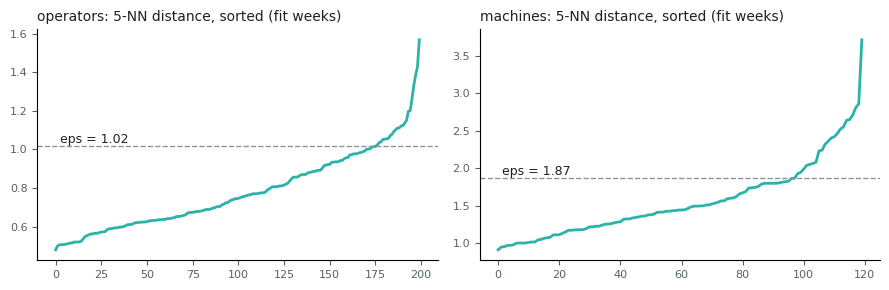

{'operator': {'eps': 1.016, 'train_noise_share': 0.03}, 'machine': {'eps': 1.866, 'train_noise_share': 0.092}}


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (et, m) in zip(axes, v2.items()):
    kd = m["k_distances"]
    ax.plot(np.arange(len(kd)), kd, color="#2BB3A8", lw=2)
    ax.axhline(m["eps"], color="#8A94A0", lw=1, ls="--")
    ax.text(0, m["eps"], f" eps = {m['eps']:.2f}", va="bottom", fontsize=9, color="#1B2128")
    ax.set_title(f"{et}s: 5-NN distance, sorted (fit weeks)", fontsize=10, loc="left", color="#1B2128")
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    ax.tick_params(colors="#55606B", labelsize=8)
fig.tight_layout(); fig.savefig(ART / "k_distance.png", dpi=120, facecolor="white"); plt.show()
print({et: {"eps": round(m["eps"], 3), "train_noise_share": round(m["train_noise_share"], 3)} for et, m in v2.items()})

In [22]:
outl = out[out.is_outlier]
by = out.assign(z_rule=out.outlier_reason.fillna("").str.contains("far "),
                noise_only=out.outlier_reason.fillna("").str.startswith("Unusual combination"))
print(by.groupby("entity_type")[["is_outlier", "z_rule", "noise_only"]].mean().round(3))
for r in outl.sort_values("week_start").groupby("entity_type").head(4).itertuples():
    print(f"{r.entity_type} {r.entity_id} week {r.week_start}: {r.outlier_reason}")

             is_outlier  z_rule  noise_only
entity_type                                
machine           0.154   0.115       0.038
operator          0.054   0.008       0.046
machine M01 week 2026-06-01: Machine anomalies per 10 h 0.31 is far above normal for an excavator (typical 0.04, z +3.1).
machine M12 week 2026-06-01: Fuel per productive hour 28.0 L/h is far above normal for an articulated truck (typical 26.1 L/h, z +2.9).
operator OP06 week 2026-06-08: Unusual combination this week: high output per productive hour (z +1.9) and low task time vs estimate (z -1.6), unlike any usual pattern.
machine M03 week 2026-06-08: Output per productive hour 193.2/h is far above normal for a wheel loader (typical 140.5/h, z +2.7).
machine M09 week 2026-06-15: Idle time 26.8% is far above normal for a wheel loader (typical 16.9%, z +2.5).
operator OP11 week 2026-06-29: Unusual combination this week: high machine anomalies per 10 h (z +2.1) and high safety events per 10 h (z +1.8), unlike any us

In [23]:
# evaluation: who gets flagged
oo = out[out.entity_type == "operator"]
pd.crosstab(oo.entity_id.map(personality).rename("personality"), oo.is_outlier, normalize="index").round(2)

is_outlier,False,True
personality,,
aggressive,0.88,0.12
average,0.97,0.03
efficient,0.95,0.05
idler,0.95,0.05
novice,0.88,0.12


## 8 — PCA 2-D scatter for the manager dashboard
PCA on the same space KMeans sees, fitted on the fit weeks. Colours are design.md categorical
tokens in the order teal · saffron · steel · sand · violet. That order passes the
colour-blind separation check on the dark `cab-surface` panel. Sand is low-chroma, so every
cluster also has its own marker shape and a direct label at its centroid. `pca_points.json`
holds the coordinates for the Recharts version.

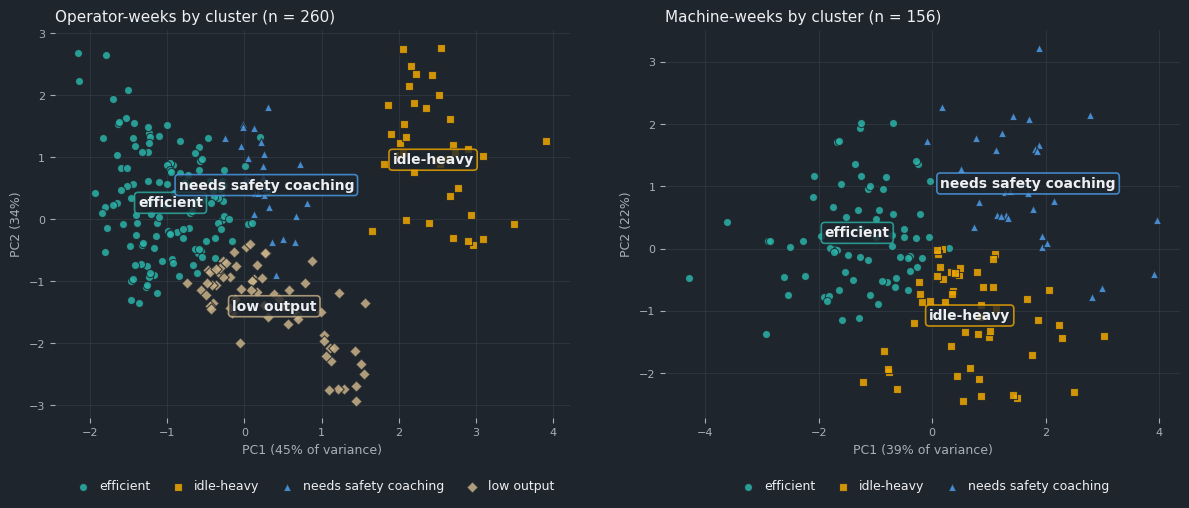

In [24]:
PALETTE = ["#2BB3A8", "#F2A900", "#4C9EEB", "#C9B28A", "#9B7BE0"]
MARKERS = ["o", "s", "^", "D", "v"]
# colour and marker follow the cluster name (same name = same colour in both panels), fixed order
names = [n for et in C.ENTITY_TYPES for n in v2[et]["cluster_labels"].values()]
ORDER = ["efficient", "idle-heavy", "needs safety coaching", "low output"]
ORDER += sorted(set(names) - set(ORDER))
assert len(ORDER) <= len(PALETTE), "more cluster names than categorical tokens"
STYLE = {n: (PALETTE[i], MARKERS[i]) for i, n in enumerate(ORDER)}
SURF, TXT, TXT2, GRID = "#1F252C", "#EDEFF2", "#A7B0BA", "#3A444F"
points = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), facecolor=SURF)
for ax, et in zip(axes, C.ENTITY_TYPES):
    m = v2[et]; e = ew[ew.entity_type == et]
    xy = m["pca"].transform(C.cluster_space(e, m)); cl = predict(e, m)
    ev = m["pca"].explained_variance_ratio_
    ax.set_facecolor(SURF)
    for c in sorted(range(m["k"]), key=lambda c: ORDER.index(m["cluster_labels"][c])):
        s = cl == c
        col, mk = STYLE[m["cluster_labels"][c]]
        ax.scatter(xy[s, 0], xy[s, 1], s=34, marker=mk, color=col, alpha=0.85,
                   edgecolors=SURF, linewidths=0.8, label=m["cluster_labels"][c])
        cx, cy = m["pca"].transform(m["kmeans"].cluster_centers_[[c]])[0]
        ax.annotate(m["cluster_labels"][c], (cx, cy), fontsize=10, color=TXT, weight="bold",
                    ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.25", fc=SURF, ec=STYLE[m["cluster_labels"][c]][0], lw=1.2, alpha=0.8))
    ax.set_xlabel(f"PC1 ({ev[0]:.0%} of variance)", color=TXT2, fontsize=9)
    ax.set_ylabel(f"PC2 ({ev[1]:.0%})", color=TXT2, fontsize=9)
    ax.set_title(f"{et.capitalize()}-weeks by cluster (n = {len(e)})", color=TXT, fontsize=11, loc="left")
    ax.grid(color=GRID, lw=0.6, alpha=0.6); ax.set_axisbelow(True)
    ax.tick_params(colors=TXT2, labelsize=8)
    for s in ax.spines.values(): s.set_visible(False)
    ax.legend(frameon=False, fontsize=9, labelcolor=TXT, loc="upper center",
              bbox_to_anchor=(0.5, -0.13), ncol=4, handletextpad=0.3, columnspacing=1.2)
    load = pd.DataFrame(m["pca"].components_.T, index=FEATURE_COLUMNS, columns=["pc1", "pc2"]).round(3)
    points[et] = {"explained_variance": ev.round(3).tolist(), "loadings": load.to_dict("index"),
                  "points": [{"entity_id": r.entity_id, "week_start": str(r.week_start),
                              "pc1": round(float(x), 3), "pc2": round(float(y), 3), "cluster_id": int(c),
                              "cluster_label": m["cluster_labels"][int(c)]}
                             for r, (x, y), c in zip(e.itertuples(), xy, cl)]}
fig.tight_layout()
fig.savefig(ART / "pca_scatter.png", dpi=130, facecolor=SURF, bbox_inches="tight")
(ART / "pca_points.json").write_text(json.dumps(points))
plt.show()

## 9 — Metrics and result sheet

In [25]:
import sklearn
op_out = out[out.entity_type == "operator"]
metrics = {
    "model_name": "clustering", "version": "v2",
    "versions": {"sklearn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__},
    "split": {"fit_weeks": config["fit_weeks"], "fit_days": [1, 70], "holdout_days": [71, 90],
              "by": "week_start of shift_date"},
    "rows": ew.groupby(["entity_type", "fit"]).size().rename(lambda b: "fit" if b is True else "holdout", level=1)
              .unstack().to_dict("index"),
    "params": {"kmeans": {"n_init": 10, "random_state": RANDOM_STATE, "k_range": list(C.K_RANGE)},
               "dbscan_min_samples": C.DBSCAN_MIN_SAMPLES, "z_outlier": C.Z_OUTLIER,
               "min_fit_hours": C.MIN_FIT_HOURS},
    "anomaly_events": len(anomaly_events),
    "v1_spec": {"eval": v1_eval, **{et: {"k": m["k"], "silhouette": m["silhouette"],
                                         "cluster_labels": m["cluster_labels"]} for et, m in v1.items()}},
    "v2_tuned": {"eval": v2_eval, **{et: {"k": m["k"], "silhouette": m["silhouette"],
                                          "cluster_labels": m["cluster_labels"], "eps": m["eps"],
                                          "train_noise_share": m["train_noise_share"],
                                          "weights": dict(zip(FEATURE_COLUMNS, map(float, m["weights"]))),
                                          "centroids_z": m["centroids_z"].round(3).to_dict("index")}
                                     for et, m in v2.items()}},
    "reliability_icc": rel.to_dict(),
    "personality_crosstab_fit": ct_fit.to_dict(), "personality_crosstab_holdout": ct_hold.to_dict(),
    "machine_same_cluster_share": float(stay.mean()),
    "ari_reference_merge_efficient_average": ari_merge_ceiling,
    "outlier_share": out.groupby("entity_type").is_outlier.mean().to_dict(),
    "efficiency_by_personality": op_out.groupby(op_out.entity_id.map(personality)).efficiency_index.mean().round(3).to_dict(),
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2, default=lambda x: x.item() if hasattr(x, "item") else str(x)))
sizes = {p.name: p.stat().st_size for p in ART.iterdir()}
print(f"total {sum(sizes.values()) / 1e6:.2f} MB"); sizes

total 0.27 MB


{'config.json': 7328,
 'feature_list.json': 137,
 'fleet_metrics_weekly.csv': 42973,
 'k_distance.png': 34821,
 'metrics.json': 7641,
 'model_machine.joblib': 5773,
 'model_operator.joblib': 9835,
 'pca_points.json': 54224,
 'pca_scatter.png': 101614,
 'README.md': 7211}

In [26]:
e1, e2 = v1_eval, v2_eval
mo, mm = v2["operator"], v2["machine"]
lab = lambda m: ", ".join(f"{c} {n}" for c, n in m["cluster_labels"].items())
sil = lambda m: " · ".join(f"k={k}: {s:.3f}" for k, s in m["silhouette"].items())
ct_md = lambda ct: "| personality | " + " | ".join(ct.columns) + " |\n|---|" + "---|" * len(ct.columns) + "\n" + \
    "\n".join(f"| {p} | " + " | ".join(str(v) for v in row) + " |" for p, row in ct.iterrows())
rel_md = "\n".join(f"| {f} | {rel.loc[f, 'v1 operator']:.2f} | {rel.loc[f, 'v2 operator']:.2f} | "
                   f"{w:.2f} | {rel.loc[f, 'v2 machine']:.2f} |" for f, w in zip(FEATURE_COLUMNS, mo["weights"]))
eff = metrics["efficiency_by_personality"]
_ex = out[out.is_outlier].sort_values(["entity_type", "week_start"])
example_reasons = " / ".join(f'{r.entity_id} week of {r.week_start}: "{r.outlier_reason}"'
                             for r in [_ex[_ex.outlier_reason.str.contains("far ")].iloc[0],
                                       _ex[_ex.outlier_reason.str.startswith("Unusual")].iloc[-1]])
purity_txt = "On the fit weeks, " + "; ".join(
    f"{p} → {main[p].split(': ')[1]} {purity[p]:.0%}" for p in purity.sort_values(ascending=False).index) + "."
eff_txt = ", ".join(f"{p} {v:+.2f}" for p, v in sorted(eff.items(), key=lambda kv: -kv[1]))
osh = metrics["outlier_share"]
ok = e2["ari_operator_weeks_holdout"] >= 0.5
readme = f"""# Fleet clustering v2 — result sheet

Weekly operator and machine metrics (models.md §4), standardised within machine type, clustered with
StandardScaler + KMeans (k 3–5 by silhouette), named from the centroids, ranked by the efficiency index,
and screened for outliers (|z| > 2.5 or DBSCAN noise). Fitted on weeks 1–10 (days 1–70), holdout weeks
11–13 (days 71–90). Notebook: `ml/03_clustering.ipynb`. Inference: `ml/inference/clustering.py` →
`cluster_week(metrics_df)`, returning `fleet_metrics_weekly` rows.

**In plain words:** The operator clusters recover the hidden personalities with an adjusted Rand index of
**{e2['ari_operator_weeks_holdout']:.2f} on unseen weeks** ({e2['ari_operator_weeks_fit']:.2f} on the fit weeks), and **{e2['ari_operators_mean_week']:.2f}** when each
operator is placed by their average week. {'That clears' if ok else 'That is below'} the 0.5 bar. The models.md §4 version as written scored
{e1['ari_operator_weeks_holdout']:.2f} / {e1['ari_operator_weeks_fit']:.2f}. One tuning round fixed two causes found without the labels (below).
{purity_txt}
**Why the index stays {'above' if ok else 'below'} 0.5:** silhouette picks k = {mo['k']}, so the two largest groups (efficient
25 %, average 40 %) share the "efficient" cluster. A perfect 4-cluster answer that merged only those two would score
{ari_merge_ceiling:.2f}. The index punishes merging large groups hard, even when every other group is found cleanly.

![PCA scatter](pca_scatter.png)

| Operator clusters | ARI fit weeks (n={e2['n_fit']}) | ARI holdout weeks (n={e2['n_holdout']}) | ARI per operator (average week, n=20) |
|---|---|---|---|
| v1 — models.md §4 as written | {e1['ari_operator_weeks_fit']:.3f} | {e1['ari_operator_weeks_holdout']:.3f} | {e1['ari_operators_mean_week']:.3f} |
| **v2 — ships** | **{e2['ari_operator_weeks_fit']:.3f}** | **{e2['ari_operator_weeks_holdout']:.3f}** | **{e2['ari_operators_mean_week']:.3f}** |

**Operators:** k = {mo['k']} ({sil(mo)}): {lab(mo)}.
**Machines:** k = {mm['k']} ({sil(mm)}): {lab(mm)}.

Holdout weeks, personality × cluster (operator-weeks):

{ct_md(ct_hold)}

## Why v1 missed 0.5, and the one tuning round
Reliability = ICC(1), the share of a feature's operator-week variance that lies between operators
(label-free, fit weeks):

| Feature | operator, v1 | operator, v2 | v2 operator weight √ICC | machine |
|---|---|---|---|---|
{rel_md}

1. **time_ratio against the planning p50 hides pace.** The task-time p50 already contains the operator's
   usual pace (`operator_avg_time_ratio`), so a slow operator gets a slow estimate and a ratio near 1. v2 divides by
   the **fleet p50** (same model, operator history unknown), i.e. what the job takes a typical operator in
   those conditions. The planning p50 in `tasks.predicted_p50_min` is unchanged.
2. **Noisy features set the cluster boundaries.** Anomaly and safety events are a handful per operator-week
   ({len(anomaly_events)} detector fault events fleet-wide in 90 days), so they are mostly Poisson noise. StandardScaler gave
   them the same weight as idle time. v2 weights each operator feature by √ICC, so each contributes its
   between-operator variance. **Machines keep equal weights**: their reliabilities are ~0 because a machine's
   week mostly reflects who drove it, so machine clusters describe the week of use.

The personality labels were not used to choose either change. They were read only to score the result.
**What stays imperfect:** productivity per hour is stable per operator, but it tracks skill (experience
varies inside each personality), which is a real pattern the labels don't hold. Average operators fall
between efficient and slow: about two thirds of their weeks land in "efficient", the rest in "low output".
Machine-weeks stay in the machine's most common cluster {stay.mean():.0%} of the time (1/k = {1 / mm['k']:.0%} if random).

## Efficiency index, ranking and outliers
`0.35·z(productivity) − 0.25·z(fuel/h) − 0.2·z(idle) − 0.2·z(time_ratio)` on the within-type z; rank 1 = best
in the site for that week and entity type. Mean operator index by personality: {eff_txt}.
Outliers: {osh.get('operator', 0):.0%} of operator-weeks, {osh.get('machine', 0):.0%} of machine-weeks. DBSCAN eps from the k-distance
knee ({mo['eps']:.2f} operators, {mm['eps']:.2f} machines; noise on the fit weeks {mo['train_noise_share']:.0%} / {mm['train_noise_share']:.0%}).
Each outlier row names its feature(s) in `outlier_reason`, e.g. {example_reasons} These are for the manager to
verify (`verified_by`), not verdicts.

## Method notes
- Metrics per entity × week × machine type ("segment"): productive_hours = non-idle engine-on hours;
  fuel_per_productive_hour = all fuel ÷ productive hours; idle_pct = idle ÷ engine-on minutes;
  productivity_per_hour = completed quantity ÷ productive hours (m³, tons for haul); time_ratio = Σ actual ÷
  Σ fleet p50 over completed tasks; anomaly and safety events per 10 engine-on hours. Weeks start on the
  Monday of the shift date.
- Each segment is z-scored against its entity_type × machine_type mean / std on the fit weeks; an operator's
  week is the productive-hours-weighted mean of their per-type z. For operators the stored productivity mixes
  m³ and tons when they drove a truck that week (the z-scores don't).
- `anomaly_count` = `machine_fault` events of `ml.inference.anomaly` (sensor glitches excluded), never
  `anomaly_label`. `safety_event_count` leaves out `fatigue_high`: it follows the roster (night shifts), not
  operating behaviour; fatigue has its own path (models.md §5, §10).
- The task-time model trained on days 1–70, so time_ratio on the fit weeks uses in-sample p50s.
- Cluster names from the centroids: "needs safety coaching" (highest safety z ≥ 0.5), "idle-heavy" (highest
  idle z ≥ 0.5), "efficient" (lowest time_ratio + fuel), others after their strongest trait or "average".
  The training recommender (models.md §10) keys on "needs safety coaching".
- `personality` is read only in the evaluation cells.
- Artifacts: `model_operator.joblib` / `model_machine.joblib` (scaler, weights, KMeans, PCA, DBSCAN core points,
  eps; compress=3), `config.json` (type scalers, cluster names, weights), `feature_list.json`, `metrics.json`,
  `pca_scatter.png`, `pca_points.json` (dashboard scatter), `k_distance.png`, `fleet_metrics_weekly.csv` (all
  13 weeks, ready to load). They load only with the versions pinned in `ml/requirements.txt`. Not yet logged to
  `model_runs`; `metrics.json` has the fields that table needs.
"""
(ART / "README.md").write_text(readme, encoding="utf-8")
print(readme)

# Fleet clustering v2 — result sheet

Weekly operator and machine metrics (models.md §4), standardised within machine type, clustered with
StandardScaler + KMeans (k 3–5 by silhouette), named from the centroids, ranked by the efficiency index,
and screened for outliers (|z| > 2.5 or DBSCAN noise). Fitted on weeks 1–10 (days 1–70), holdout weeks
11–13 (days 71–90). Notebook: `ml/03_clustering.ipynb`. Inference: `ml/inference/clustering.py` →
`cluster_week(metrics_df)`, returning `fleet_metrics_weekly` rows.

**In plain words:** The operator clusters recover the hidden personalities with an adjusted Rand index of
**0.42 on unseen weeks** (0.45 on the fit weeks), and **0.41** when each
operator is placed by their average week. That is below the 0.5 bar. The models.md §4 version as written scored
0.36 / 0.37. One tuning round fixed two causes found without the labels (below).
On the fit weeks, aggressive → needs safety coaching 100%; novice → low output 100%; idler → idle-heavy 100%; effic